# Fuzzy SVM sur le dataset Sonar (Mines vs Rocks) 

In [25]:
# pip install ucimlrepo scikit-learn fsvm matplotlib seaborn pandas numpy

In [26]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from fsvm import FuzzySVC   # FuzzySVC compatible scikit-learn

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style("whitegrid")

In [27]:

np.random.seed(42)
sns.set_style("whitegrid")

# Chargement du dataset Sonar
print("Chargement du dataset Sonar (Mines vs Rocks)...")
sonar = fetch_ucirepo(id=151)
X = sonar.data.features

# Récupération robuste de la cible (la colonne peut varier selon la source)
targets = sonar.data.targets
if isinstance(targets, pd.DataFrame):
    if 'Class' in targets.columns:
        y_str = targets['Class']
    else:
        y_str = targets.iloc[:, 0]
else:
    y_str = pd.Series(targets)

# Conversion : M (mine) = +1, R (rock) = -1
y = y_str.map({'M': 1, 'R': -1}).values

print(f"Samples : {X.shape[0]} | Features : {X.shape[1]}")
print(f"Mines (+1) : {(y == 1).sum()} ({(y == 1).mean():.1%})")
print(f"Roches (-1): {(y == -1).sum()} ({(y == -1).mean():.1%})")

Chargement du dataset Sonar (Mines vs Rocks)...
Samples : 208 | Features : 60
Mines (+1) : 111 (53.4%)
Roches (-1): 97 (46.6%)


In [28]:

# Split train / val / test =
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

Train: 145 | Val: 31 | Test: 32


In [29]:
# Recherche d'hyperparamètres sur le set de validation (Fuzzy SVM uniquement)
print("\nRecherche d'hyperparamètres Fuzzy SVM avec le set de validation...")
C_grid = [0.1, 1.0, 10.0]
gamma_grid = ['scale', 0.1, 0.01]

best_fuzzy = {"val_auc": -np.inf, "C": None, "gamma": None}
svm_fuzzy = None
search_history = []
iter_idx = 0

for C in C_grid:
    for gamma in gamma_grid:
        iter_idx += 1
        model = FuzzySVC(kernel='rbf', C=C, gamma=gamma, probability=True, random_state=42)
        model.fit(X_train, y_train)

        val_scores = model.predict_proba(X_val)[:, 1]
        val_auc = roc_auc_score(y_val, val_scores)

        # Courbe d'evolution demandee: suivi Val/Test a chaque essai
        test_scores = model.predict_proba(X_test)[:, 1]
        test_auc = roc_auc_score(y_test, test_scores)

        search_history.append({
            "iter": iter_idx,
            "C": C,
            "gamma": gamma,
            "val_auc": val_auc,
            "test_auc": test_auc
        })

        if val_auc > best_fuzzy["val_auc"]:
            best_fuzzy = {"val_auc": val_auc, "C": C, "gamma": gamma}
            svm_fuzzy = model

print(f"Fuzzy SVM - meilleur C={best_fuzzy['C']}, gamma={best_fuzzy['gamma']}, Val AUC={best_fuzzy['val_auc']:.3f}")



Recherche d'hyperparamètres Fuzzy SVM avec le set de validation...
Fuzzy SVM - meilleur C=10.0, gamma=scale, Val AUC=0.979


In [30]:
# Résumé validation + évaluation finale sur test (Fuzzy SVM uniquement)
print("Résultat de sélection sur validation:")
print(f"- Fuzzy SVM: C={best_fuzzy['C']}, gamma={best_fuzzy['gamma']}, Val AUC={best_fuzzy['val_auc']:.3f}")

print("\nÉvaluation finale sur le test set (jamais vu à l'entraînement):")
y_pred = svm_fuzzy.predict(X_test)
y_score = svm_fuzzy.predict_proba(X_test)[:, 1]

print("\nFuzzy SVM")
print(classification_report(y_test, y_pred, target_names=['Rochers (-1)', 'Mines (+1)']))
print(f"ROC AUC (test) : {roc_auc_score(y_test, y_score):.3f}")

Résultat de sélection sur validation:
- Fuzzy SVM: C=10.0, gamma=scale, Val AUC=0.979

Évaluation finale sur le test set (jamais vu à l'entraînement):

Fuzzy SVM
              precision    recall  f1-score   support

Rochers (-1)       0.93      0.93      0.93        15
  Mines (+1)       0.94      0.94      0.94        17

    accuracy                           0.94        32
   macro avg       0.94      0.94      0.94        32
weighted avg       0.94      0.94      0.94        32

ROC AUC (test) : 0.984


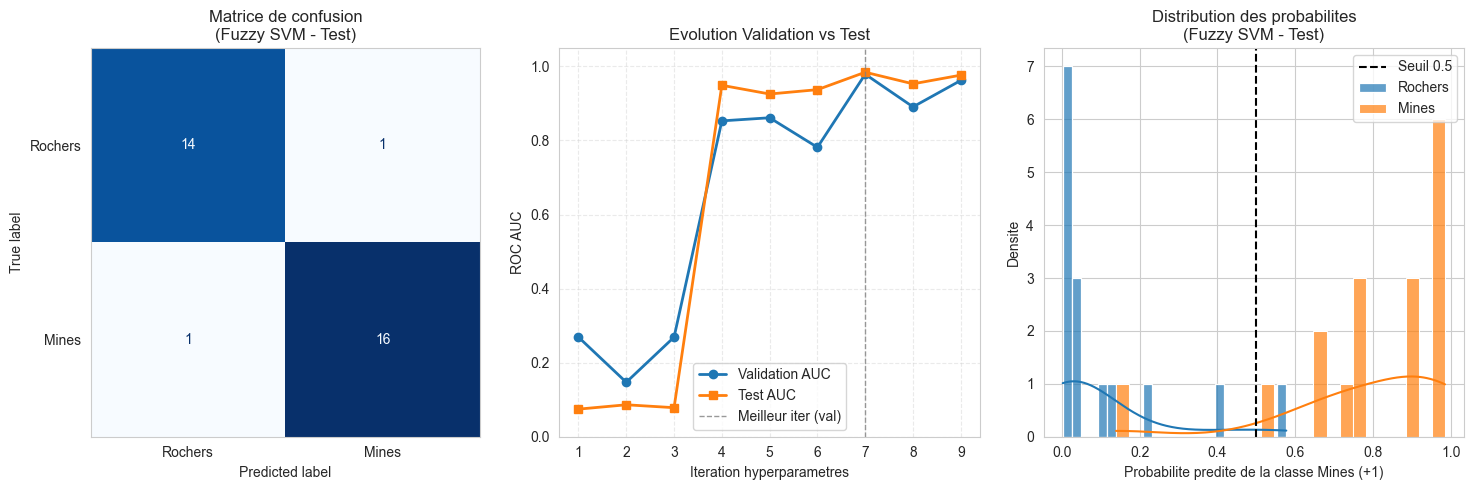

In [31]:
# Visualisations
fig = plt.figure(figsize=(15, 5))
gs = plt.GridSpec(1, 3, figure=fig)

# 1) Matrice de confusion (test)
ax1 = fig.add_subplot(gs[0, 0])
cm = confusion_matrix(y_test, svm_fuzzy.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rochers', 'Mines'])
disp.plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.grid(False)
ax1.set_title('Matrice de confusion\n(Fuzzy SVM - Test)')

# 2) Courbe d'evolution Validation/Test
ax2 = fig.add_subplot(gs[0, 1])
iters = [h['iter'] for h in search_history]
val_curve = [h['val_auc'] for h in search_history]
test_curve = [h['test_auc'] for h in search_history]

ax2.plot(iters, val_curve, marker='o', lw=2, label='Validation AUC')
ax2.plot(iters, test_curve, marker='s', lw=2, label='Test AUC')

best_iter = max(search_history, key=lambda h: h['val_auc'])['iter']
ax2.axvline(best_iter, color='gray', linestyle='--', lw=1, alpha=0.8, label='Meilleur iter (val)')

ax2.set_ylim(0.0, 1.05)
ax2.set_xticks(iters)
ax2.set_xlabel('Iteration hyperparametres')
ax2.set_ylabel('ROC AUC')
ax2.set_title('Evolution Validation vs Test')
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.legend()

# 3) Distribution des probabilites predites (test)
ax3 = fig.add_subplot(gs[0, 2])
scores_test = svm_fuzzy.predict_proba(X_test)[:, 1]
sns.histplot(scores_test[y_test == -1], bins=25, alpha=0.7, label='Rochers', kde=True, ax=ax3)
sns.histplot(scores_test[y_test == 1], bins=25, alpha=0.7, label='Mines', kde=True, ax=ax3)
ax3.axvline(0.5, color='black', linestyle='--', lw=1.5, label='Seuil 0.5')
ax3.set_xlabel('Probabilite predite de la classe Mines (+1)')
ax3.set_ylabel('Densite')
ax3.set_title('Distribution des probabilites\n(Fuzzy SVM - Test)')
ax3.legend()

plt.tight_layout()
plt.show()